### **Pandas + Kaggle.com dataset**

In [143]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt


In [144]:
path = kagglehub.dataset_download("sootersaalu/amazon-top-50-bestselling-books-2009-2019")
df = pd.read_csv(path + "/bestsellers with categories.csv")

In [145]:
df.head()

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


In [146]:
df.shape

(550, 7)

How many books does the dataset contain?
Answer: 550

In [147]:
df.columns = ['name', 'author', 'user_rating', 'reviews', 'price', 'year', 'genre']

In [148]:
df.isna().sum()

name           0
author         0
user_rating    0
reviews        0
price          0
year           0
genre          0
dtype: int64

Are there any missing values in any of the variables?
Answer: No

In [149]:
df["genre"].unique()

array(['Non Fiction', 'Fiction'], dtype=object)

What are some unique genres?
Answer: Nonfiction, Fiction

In [150]:
df["price"].max()

np.int64(105)

Maximum price?
Answer: 105

In [151]:
df["price"].min()

np.int64(0)

Minimum price?
Answer: 0

In [152]:
df["price"].mean()

np.float64(13.1)

Average price?
Answer: 13.1

In [153]:
df["price"].median()

np.float64(11.0)

Median price?
Answer: 11

In [154]:
df["user_rating"].max()

np.float64(4.9)

What is the highest rating in the dataset? 
Answer: 4.9

In [155]:
df[df["user_rating"] == df["user_rating"].max()].shape[0]

52

How many books have this rating? 
Answer: 52

In [156]:
df.loc[df["reviews"].idxmax()]

name           Where the Crawdads Sing
author                     Delia Owens
user_rating                        4.8
reviews                          87841
price                               15
year                              2019
genre                          Fiction
Name: 534, dtype: object

Which book has the most reviews? 
Answer: Delia Owens' *Where the Crawdads Sing*

In [157]:
df[df["year"] == 2015].sort_values("price", ascending=False).head(50)

,name,author,user_rating,reviews,price,year,genre
277,Publication Manual of the American Psychologic...,American Psychological Association,4.5,8580,46,2015,Non Fiction
501,Thug Kitchen: The Official Cookbook: Eat Like ...,Thug Kitchen,4.6,11128,23,2015,Non Fiction
132,Go Set a Watchman: A Novel,Harper Lee,3.6,14982,19,2015,Fiction
382,The Girl on the Train,Paula Hawkins,4.1,79446,18,2015,Fiction
174,Humans of New York : Stories,Brandon Stanton,4.9,2812,17,2015,Non Fiction
310,StrengthsFinder 2.0,Gallup,4.0,5069,17,2015,Non Fiction
335,The 7 Habits of Highly Effective People: Power...,Stephen R. Covey,4.7,4725,16,2015,Non Fiction
483,The Whole30: The 30-Day Guide to Total Health ...,Melissa Hartwig Urban,4.6,7508,16,2015,Non Fiction
492,The Wright Brothers,David McCullough,4.7,6169,16,2015,Non Fiction
34,Being Mortal: Medicine and What Matters in the...,Atul Gawande,4.8,11113,15,2015,Non Fiction


Of the books that made it into the Top 50 in 2015, which one is the most expensive? 
Answer: 46

In [158]:
df[(df["year"] == 2010) & (df["genre"] == "Fiction")].shape[0]

20

How many fiction books made it into the Top 50 in 2010? 
Answer: 20

In [159]:
df[(df["user_rating"] == 4.9) & (df["year"].isin([2010, 2011]))].shape[0]

1

How many books with a rating of 4.9 made it into the rankings in 2010 and 2011? 
Answer: 1

In [160]:
df[(df["year"] == 2015) & (df["price"] < 8)].sort_values("price")

,name,author,user_rating,reviews,price,year,genre
507,To Kill a Mockingbird,Harper Lee,4.8,26234,0,2015,Fiction
54,Creative Haven Creative Cats Coloring Book (Ad...,Marjorie Sarnat,4.8,4022,4,2015,Non Fiction
206,Knock-Knock Jokes for Kids,Rob Elliott,4.5,3673,4,2015,Non Fiction
111,First 100 Words,Roger Priddy,4.7,17323,4,2015,Non Fiction
210,Laugh-Out-Loud Jokes for Kids,Rob Elliott,4.6,6990,4,2015,Non Fiction
123,Giraffes Can't Dance,Giles Andreae,4.8,14038,4,2015,Fiction
55,Creative Haven Owls Coloring Book (Adult Color...,Marjorie Sarnat,4.8,3871,5,2015,Non Fiction
63,Dear Zoo: A Lift-the-Flap Book,Rod Campbell,4.8,10922,5,2015,Fiction
224,Love You Forever,Robert Munsch,4.8,18613,5,2015,Fiction
478,The Very Hungry Caterpillar,Eric Carle,4.9,19546,5,2015,Fiction


Which book is last on the sorted list? 
Answer: Old School (Diary of a Wimpy Kid #10)

In [161]:
df.groupby("genre")["price"].agg(["min", "max"])

,min,max
genre,,
Fiction,0,82
Non Fiction,0,105


Maximum price for the Fiction genre: 82

Minimum price for the Fiction genre: 0

Maximum price for the Non-Fiction genre: 105

Minimum price for the Non-Fiction genre: 0

In [162]:
author_count = df.groupby("author")["name"].count()
author_count.head()

author
Abraham Verghese              2
Adam Gasiewski                1
Adam Mansbach                 1
Adir Levy                     1
Admiral William H. McRaven    1
Name: name, dtype: int64

In [163]:
author_count.shape

(248,)

What are the dimensions of the table? Answer: (248,1)

In [164]:
author_count.sort_values(ascending=False).head(1)

author
Jeff Kinney    12
Name: name, dtype: int64

Which author has the most books? Answer: Jeff Kinney
How many books has this author written? Answer: 12

In [165]:
author_rating = df.groupby("author")["user_rating"].mean()
author_rating.head()

author
Abraham Verghese              4.6
Adam Gasiewski                4.4
Adam Mansbach                 4.8
Adir Levy                     4.8
Admiral William H. McRaven    4.7
Name: user_rating, dtype: float64

In [166]:
author_rating.reset_index().sort_values('user_rating').head(1)

,author,user_rating
71,Donna Tartt,3.9


Which author has the lowest average rating? 
Answer: Donna Tartt
What is this author's average rating? 
Answer: 3.9

In [175]:
result = pd.concat([author_count, author_rating], axis=1)
result.columns = ["books_count", "avg_rating"]
result.sort_values(["books_count", "avg_rating"])

,books_count,avg_rating
author,,
Muriel Barbery,1,4.000000
Chris Cleave,1,4.100000
Ian K. Smith M.D.,1,4.100000
Pierre Dukan,1,4.100000
Elizabeth Strout,1,4.200000
...,...,...
American Psychological Association,10,4.500000
Suzanne Collins,11,4.663636
Gary Chapman,11,4.736364


Which author is first on the list?
Answer: Muriel Barbery

<Axes: >

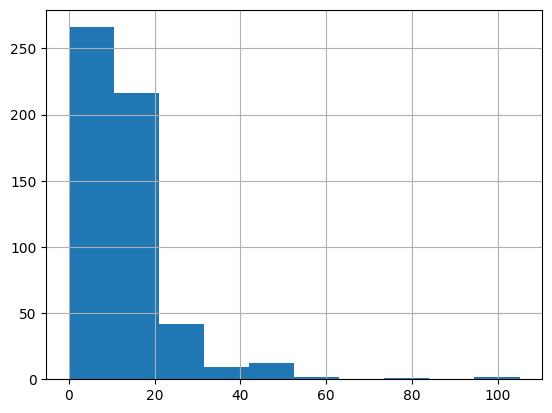

In [176]:
df['price'].hist()

<Axes: >

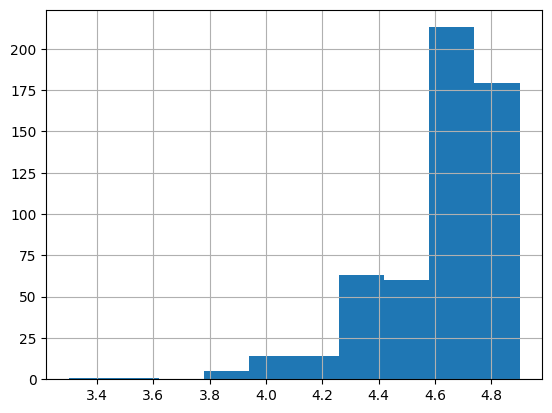

In [177]:
df['user_rating'].hist()

<Axes: xlabel='year'>

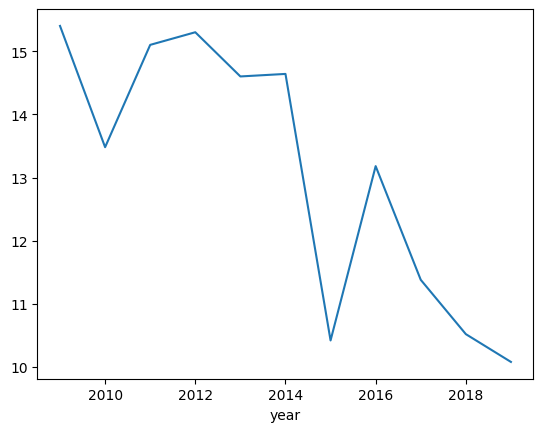

In [178]:
df.groupby('year')['price'].mean().plot()

<Axes: xlabel='genre'>

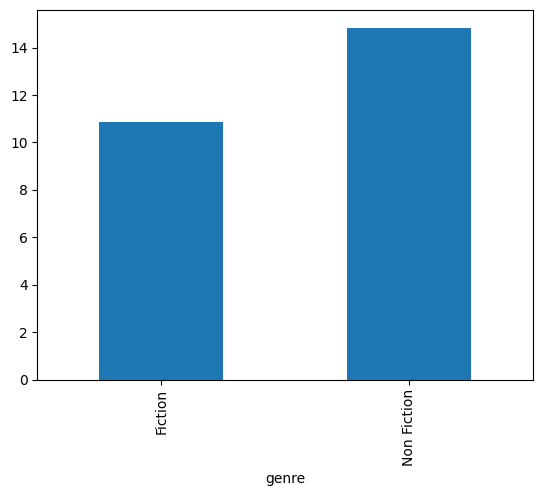

In [179]:
df.groupby('genre')['price'].mean().plot(kind='bar')